# Thresholding an image with pyclesperanto

This notebook demonstrates several ways to binarize the `blobs.png` sample image with
`pyclesperanto`: a manual/logical-operator threshold, and the automatic `Otsu`, `mean`, and
`Yen` threshold methods.

In [11]:
import numpy as np
from skimage.io import imread
import pyclesperanto as cle

cle.select_device()

(OpenCL) Apple M5 Max (OpenCL 1.2)
	Vendor:                      Apple
	Driver Version:              1.2 1.0
	Device Type:                 GPU
	Compute Units:               40
	Global Memory Size:          53084 MB
	Local Memory Size:           0 MB
	Maximum Buffer Size:         9953 MB
	Max Clock Frequency:         1000 MHz
	Image Support:               Yes

## Load the example image

array([[ 40,  32,  24, ..., 216, 200, 200],
       [ 56,  40,  24, ..., 232, 216, 216],
       [ 64,  48,  24, ..., 240, 232, 232],
       ...,
       [ 72,  80,  80, ...,  48,  48,  48],
       [ 80,  80,  80, ...,  48,  48,  48],
       [ 96,  88,  80, ...,  48,  48,  48]], shape=(254, 256), dtype=uint8, mtype=buffer)
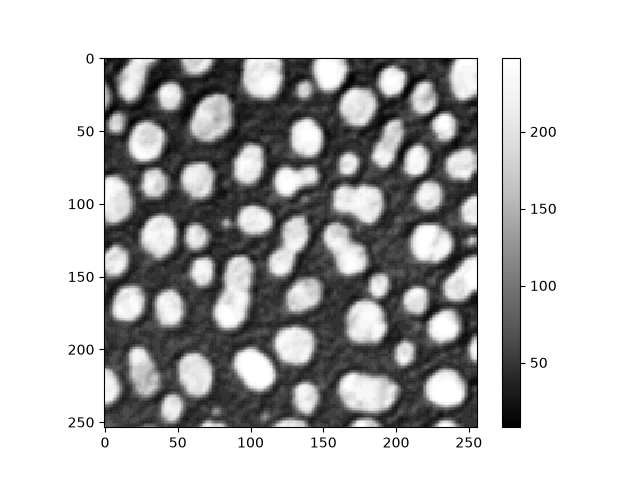
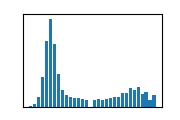

In [12]:
image = cle.push(imread('https://samples.fiji.sc/blobs.png').squeeze())
image

## 1. Manual threshold with a logical operator

The simplest way to binarize an image is to compare it against a fixed intensity value using a
logical operator (`>`, `>=`, `<`, `<=`, `==`). The result is a binary mask, same as
`cle.greater_constant()`.

array([[0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]], shape=(254, 256), dtype=uint8, mtype=buffer)
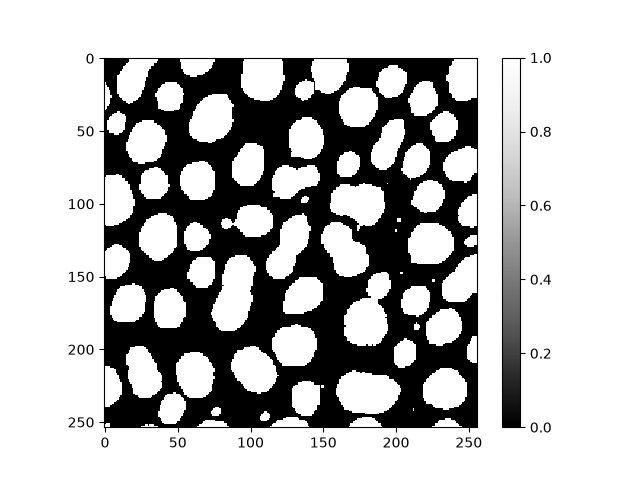
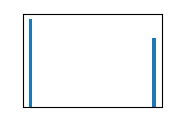

In [13]:
manual_threshold = 75
binary_manual = image > manual_threshold
binary_manual

## 2. Otsu threshold

`cle.threshold_otsu()` automatically finds a threshold value that minimizes intra-class
intensity variance (Otsu et al., 1979).

array([[0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(254, 256), dtype=uint8, mtype=buffer)
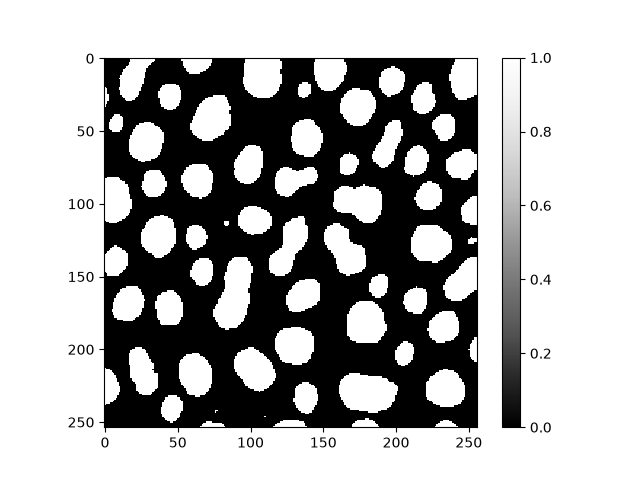
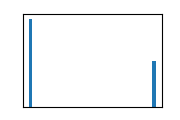

In [14]:
binary_otsu = cle.threshold_otsu(image)
binary_otsu

## 3. Mean threshold

`cle.threshold_mean()` binarizes using the global average intensity of the image as the
threshold value.

array([[0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(254, 256), dtype=uint8, mtype=buffer)
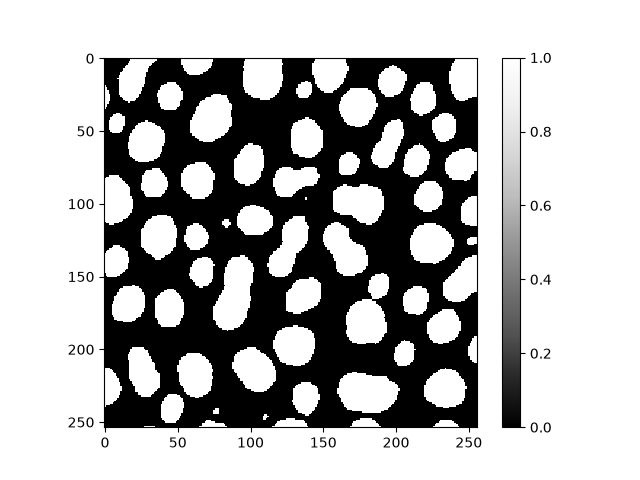
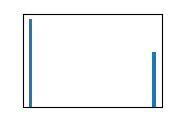

In [15]:
binary_mean = cle.threshold_mean(image)
binary_mean

## 4. Yen threshold

`cle.threshold_yen()` uses Yen's maximum correlation criterion method (Yen et al., 1995),
often well suited for images with a small foreground fraction.

array([[0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0]], shape=(254, 256), dtype=uint8, mtype=buffer)
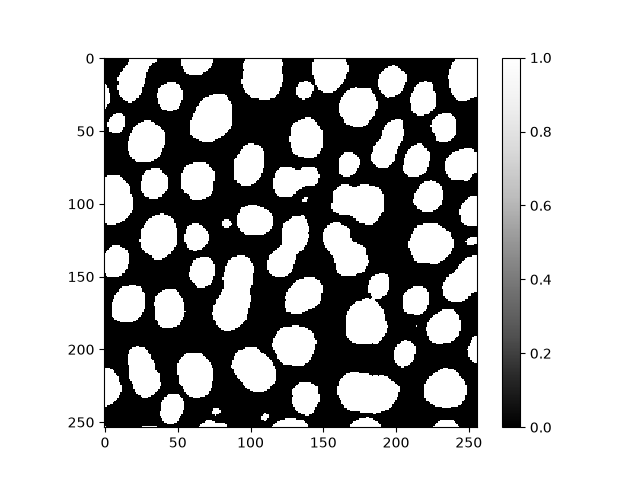
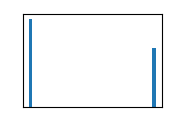

In [16]:
binary_yen = cle.threshold_yen(image)
binary_yen

## Side-by-side comparison

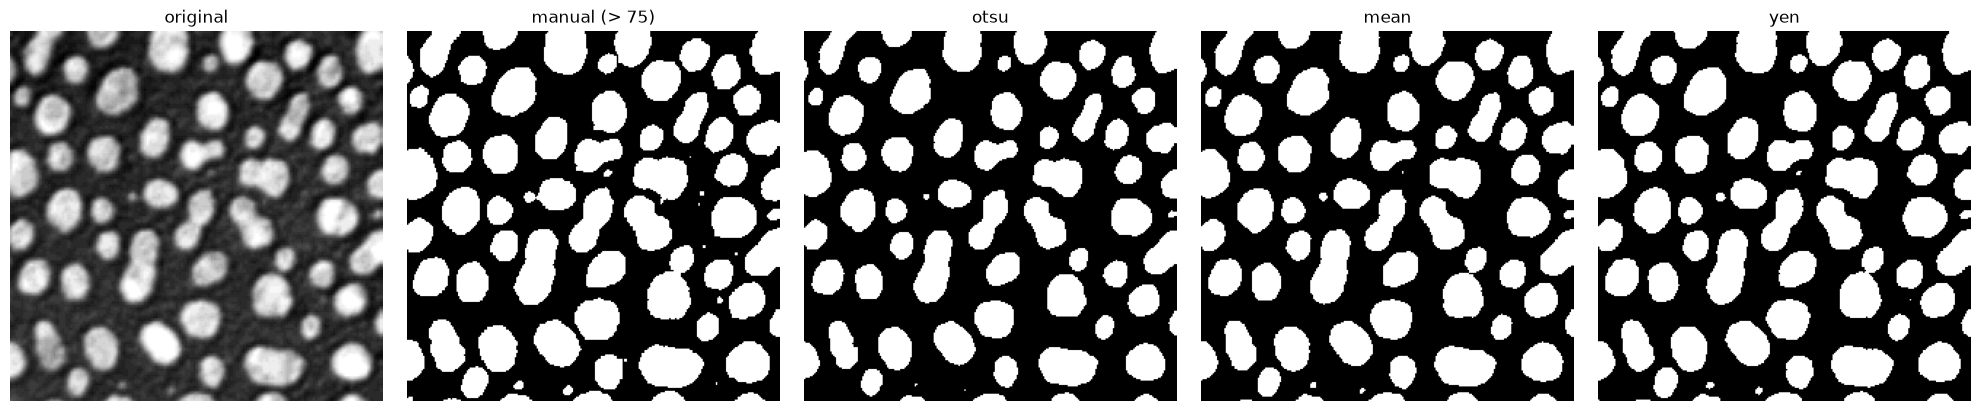

In [17]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for ax, img, title in zip(
    axs,
    [image, binary_manual, binary_otsu, binary_mean, binary_yen],
    ["original", f"manual (> {manual_threshold})", "otsu", "mean", "yen"],
):
    ax.imshow(img.get(), cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

> Threhsold output is binary (0/1 values) but GPU does not support `bool` type, data are return as `uint8` type